# Module 13 - Instruction tuning (SFT)

Use this notebook after `tests/test_sft.py` is passing and after you have saved at least one Module 10 model artifact. The notebook loads your strongest available base model by default, builds a small instruction dataset, fine-tunes with assistant-token loss masking, compares base vs SFT behavior, and saves an instruction-tuned artifact for Module 14.

The important work is not the amount of code here. It is seeing how a base model changes when the examples are consistently rendered as user/assistant turns and only assistant tokens receive loss.

## Setup

In [1]:
from pathlib import Path
import json
import math
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

from g2c.artifacts import (
    available_model_artifacts,
    baselm_artifact_exists,
    load_best_model_artifact,
    load_model_artifact_with_tokenizer,
    save_huggingface_model_artifact,
    save_model_artifact,
)
from g2c.notebook_extras.sft import plot_sft_history, train_sft_with_progress
from g2c.sampling import generate
from g2c.sft import ChatTemplate, SFTTrainer

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
print(repo_root)

/Users/colkitt/sith/toys/courses/g2c


Run the SFT tests before proceeding. In the clean scaffold this cell should fail until you implement the Module 13 TODOs in `g2c/sft/`.

In [2]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_sft.py", "-q"],
    cwd=repo_root,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "Module 13 SFT tests are not passing yet."

...........................................                              [100%]



## Load a base model

By default this loads the strongest self-trained model artifact available from Module 10. If none exists and `./baselm.sh` has been run, it falls back to `BaseLM`. Set `MODEL_ARTIFACT_NAME` to a specific artifact if you want a smaller, earlier, or external model.

In [3]:
MODEL_ARTIFACT_NAME = None  # e.g. "ShakespeareLM-1M", "StoryLM-5M", "TinyLLM-30M", "BaseLM"
TRAIN_DEVICE = "auto"
SEED = 13

available = available_model_artifacts(repo_root=repo_root)
if available:
    print("available model artifacts:")
    for artifact in available:
        print(f"  rank {artifact.rank:>2}: {artifact.name} ({artifact.display_name})")
else:
    print("No model artifacts found under artifacts/models/.")
if baselm_artifact_exists(repo_root=repo_root):
    print("external fallback available: BaseLM")

if MODEL_ARTIFACT_NAME is None:
    base_artifact = load_best_model_artifact(repo_root=repo_root, device=TRAIN_DEVICE, required=False)
    if base_artifact is None:
        if not baselm_artifact_exists(repo_root=repo_root):
            raise RuntimeError("Save a Module 10 model artifact or run ./baselm.sh for BaseLM.")
        base_artifact = load_model_artifact_with_tokenizer("BaseLM", repo_root=repo_root, device=TRAIN_DEVICE)
else:
    base_artifact = load_model_artifact_with_tokenizer(
        MODEL_ARTIFACT_NAME,
        repo_root=repo_root,
        device=TRAIN_DEVICE,
    )
sft_artifact = load_model_artifact_with_tokenizer(
    base_artifact.name,
    repo_root=repo_root,
    device=TRAIN_DEVICE,
)

base_model = base_artifact.model
sft_model = sft_artifact.model
tokenizer = sft_artifact.tokenizer
template = ChatTemplate()
pad_id = tokenizer.special_to_id.get("<|pad|>", 0)
end_id = tokenizer.special_to_id.get(template.END)

print("loaded:", base_artifact.name)
print("display:", base_artifact.display_name)
print("model vocab:", sft_model.vocab_size)
print("tokenizer vocab:", len(tokenizer.vocab))
print("max seq len:", sft_model.max_seq_len)
print("pad id:", pad_id, "end id:", end_id)
print("device:", sft_model.device)

available model artifacts:
  rank 10: ShakespeareLM-1M (ShakespeareLM)
  rank 20: StoryLM-Small (StoryLM 5M)
  rank 35: StoryLM (StoryLM 30M)
  rank 40: TinyLLM (TinyLLM 30M)
loaded: TinyLLM
display: TinyLLM 30M
model vocab: 8192
tokenizer vocab: 16381
max seq len: 512
pad id: 263 end id: 262
device: mps:0


## Sampling helpers

These helpers render the exact chat prefix used for SFT, encode it with the model's effective vocabulary size, and stop on `<|end|>` when that special token exists.

In [4]:
def chat_prompt(user_text: str, assistant_prefix: str = "") -> str:
    return (
        template.render([{"role": "user", "content": user_text}])
        + f"{template.ASSISTANT}\n"
        + assistant_prefix
    )


def encode_for_model(model, text: str) -> torch.Tensor:
    ids = tokenizer.encode_with_vocab_size(text, model.vocab_size)
    if not ids:
        raise ValueError("prompt encoded to no tokens")
    return torch.tensor(ids, dtype=torch.long)


def sample_from_model(
    model,
    prompt: str,
    *,
    max_new_tokens: int = 80,
    temperature: float = 0.7,
    top_p: float | None = 0.9,
    seed: int = SEED,
) -> str:
    prompt_ids = encode_for_model(model, prompt)
    generator = torch.Generator().manual_seed(seed)
    out = generate(
        model,
        prompt_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=1.1,
        eos_id=end_id,
        generator=generator,
    )
    new_ids = out[len(prompt_ids):]
    return tokenizer.decode([int(x) for x in new_ids.tolist()])


def sample_response(model, user_text: str, assistant_prefix: str = "", **kwargs) -> str:
    return sample_from_model(model, chat_prompt(user_text, assistant_prefix), **kwargs)


def show_comparison(prompts: list[str], *, seed: int = SEED) -> None:
    for prompt in prompts:
        print("\nPROMPT:", prompt)
        print("-" * 80)
        print("BASE:")
        print(sample_response(base_model, prompt, seed=seed))
        print("\nSFT:")
        print(sample_response(sft_model, prompt, seed=seed))

Before training, the base model is still just continuing text. The chat markers are only strings it has rarely or never seen.

In [5]:
probe = "What is the capital of France?"
print("raw prompt")
print("-" * 80)
print(sample_from_model(base_model, probe, max_new_tokens=80, seed=SEED))
print("\nchat prompt")
print("-" * 80)
print(chat_prompt(probe))
print(sample_response(base_model, probe, max_new_tokens=80, seed=SEED))

raw prompt
--------------------------------------------------------------------------------
” in Austria. Elementary and Establishment (CEP) are restricted to an area of 13,000 people in rural areas and have ensured the country’s economic systems to a specific period of time. Architectural architects and architecture have seen great cultural centers of the world’s architecture and design, as well as architecture, and architectural skills that have been 

chat prompt
--------------------------------------------------------------------------------
<|user|>
What is the capital of France?
<|assistant|>

Follow the process to build a strong foundation for a small business
How can we really make our country worthwhile?
A second step in achieving what is to make an investment decision.
It could be a fancy word for groups
Similarly, how do we start to build a strong foundation?
As a manager who has set up an investment
When investing money to buy 


## Exercise 1 - Build an instruction dataset

The starter set below lets you verify the mechanics. For the deliverable, replace or heavily edit these examples so the dataset is yours. Keep the style intentionally consistent: short prompt, short direct answer, no preamble.

In [6]:
sft_pairs = [
    {"user": "What is the capital of France?", "assistant": "Paris."},
    {"user": "What is the capital of Italy?", "assistant": "Rome."},
    {"user": "What is the capital of Japan?", "assistant": "Tokyo."},
    {"user": "What is two plus two?", "assistant": "Four."},
    {"user": "What is three times seven?", "assistant": "Twenty-one."},
    {"user": "What planet is largest in our solar system?", "assistant": "Jupiter."},
    {"user": "What is the opposite of hot?", "assistant": "Cold."},
    {"user": "What color is a clear daytime sky?", "assistant": "Blue."},
    {"user": "Who wrote Hamlet?", "assistant": "William Shakespeare."},
    {"user": "What does the Moon orbit?", "assistant": "Earth."},
    {"user": "How many sides does a triangle have?", "assistant": "Three."},
    {"user": "How many days are in a week?", "assistant": "Seven."},
    {"user": "At what Celsius temperature does water freeze?", "assistant": "Zero degrees Celsius."},
    {"user": "Name one primary color.", "assistant": "Red."},
    {"user": "Is a whale a mammal?", "assistant": "Yes."},
    {"user": "What gas do plants use from air?", "assistant": "Carbon dioxide."},
    {"user": "What does a keyboard do?", "assistant": "It types text."},
    {"user": "What unit stores computer information?", "assistant": "A bit."},
    {"user": "What is ten minus four?", "assistant": "Six."},
    {"user": "How many sides does a square have?", "assistant": "Four."},
    {"user": "What continent is Kenya in?", "assistant": "Africa."},
    {"user": "What process lets plants make sugar?", "assistant": "Photosynthesis."},
    {"user": "What does email send?", "assistant": "Messages."},
    {"user": "What is a noun?", "assistant": "A person, place, thing, or idea."},
    {"user": "What organ pumps blood?", "assistant": "The heart."},
    {"user": "Translate hello to French.", "assistant": "bonjour"},
    {"user": "Translate goodbye to Spanish.", "assistant": "adios"},
    {"user": "Make this uppercase: small.", "assistant": "SMALL"},
    {"user": "Make this lowercase: LOUD.", "assistant": "loud"},
    {"user": "Sort these words: cat, apple, banana.", "assistant": "apple, banana, cat"},
    {"user": "Rewrite this in past tense: I am happy.", "assistant": "I was happy."},
    {"user": "Summarize this: Rain fell all day.", "assistant": "It rained all day."},
    {"user": "Add excitement to: great job.", "assistant": "Great job!"},
    {"user": "Turn this into a question: You are ready.", "assistant": "Are you ready?"},
    {"user": "Make box plural.", "assistant": "boxes"},
    {"user": "Spell the number 12.", "assistant": "twelve"},
    {"user": "Return JSON for color blue.", "assistant": "{\"color\":\"blue\"}"},
    {"user": "Make this polite: Send it now.", "assistant": "Please send it now."},
    {"user": "Reverse the letters abc.", "assistant": "cba"},
    {"user": "Give one synonym for quick.", "assistant": "fast"},
    {"user": "Complete this rhyme: roses are red.", "assistant": "violets are blue"},
    {"user": "Write a one-line haiku about rain.", "assistant": "Soft rain taps rooftops."},
    {"user": "Name a brave robot.", "assistant": "Call the robot Nova."},
    {"user": "Write a tiny bedtime sentence.", "assistant": "The moon watched quietly."},
    {"user": "Invent a friendly dragon name.", "assistant": "Ember is a friendly name."},
    {"user": "Write one cheerful sentence about spring.", "assistant": "Flowers opened in the warm sun."},
    {"user": "Describe a tiny spaceship.", "assistant": "It blinked with silver lights."},
    {"user": "Write a one-line story about a key.", "assistant": "The key opened a hidden garden."},
    {"user": "Give a title for a forest story.", "assistant": "The Lantern in the Pines"},
    {"user": "Write a kind note to a friend.", "assistant": "You make hard days easier."},
    {"user": "Write one sentence about a cat.", "assistant": "The cat napped beside the window."},
]

dataset_path = repo_root / "data" / "sft" / "module13-instructions.json"
dataset_path.parent.mkdir(parents=True, exist_ok=True)
dataset_path.write_text(json.dumps(sft_pairs, indent=2) + "\n")
print(f"saved {len(sft_pairs)} pairs to {dataset_path.relative_to(repo_root)}")
assert len(sft_pairs) >= 50, "Add at least 50 instruction-response pairs."

saved 51 pairs to data/sft/module13-instructions.json


## Inspect the template and mask

The token IDs are arbitrary. The important question is which positions receive loss. User tokens and role-marker tokens should be `0`; assistant content and `<|end|>` should be `1`.

In [7]:
def messages_from_pair(pair: dict[str, str]) -> list[dict[str, str]]:
    return [
        {"role": "user", "content": pair["user"]},
        {"role": "assistant", "content": pair["assistant"]},
    ]


example_pair = sft_pairs[0]
rendered = template.render(messages_from_pair(example_pair))
encoded = template.render_with_mask(messages_from_pair(example_pair), tokenizer)
print(rendered)
print("\ntokens:", len(encoded.ids), "masked tokens:", sum(encoded.mask))
assert len(encoded.ids) == len(encoded.mask)

print("\nindex | token id | mask | decoded token")
print("-" * 72)
for i, (token_id, mask_value) in enumerate(zip(encoded.ids, encoded.mask)):
    piece = tokenizer.decode([token_id]).replace("\n", "\\n").replace("\t", "\\t")
    print(f"{i:>5} | {token_id:>8} | {mask_value:>4} | {piece!r}")

<|user|>
What is the capital of France?
<|assistant|>
Paris.<|end|>

tokens: 14 masked tokens: 4

index | token id | mask | decoded token
------------------------------------------------------------------------
    0 |      258 |    0 | '<|user|>'
    1 |       10 |    0 | '\\n'
    2 |    10827 |    0 | 'What is the '
    3 |     7812 |    0 | 'capital '
    4 |      297 |    0 | 'of '
    5 |     1216 |    0 | 'Fr'
    6 |     2807 |    0 | 'ance'
    7 |     1035 |    0 | '?\\n'
    8 |      259 |    0 | '<|assistant|>'
    9 |       10 |    0 | '\\n'
   10 |     1567 |    1 | 'Par'
   11 |      314 |    1 | 'is'
   12 |       46 |    1 | '.'
   13 |      262 |    1 | '<|end|>'


examples: 51
token length min/mean/max: 12 16.823529411764707 25
masked tokens min/mean/max: 2 5.333333333333333 10


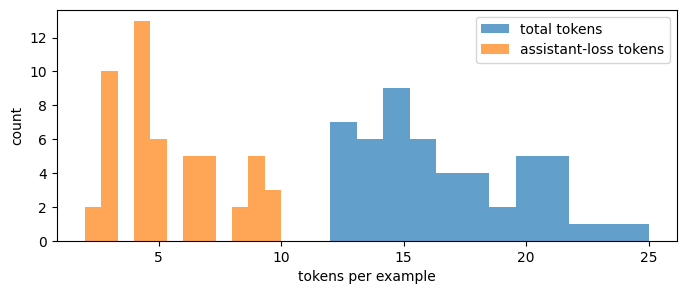

In [8]:
encoded_examples = [
    template.render_with_mask(messages_from_pair(pair), tokenizer)
    for pair in sft_pairs
]

lengths = [len(ex.ids) for ex in encoded_examples]
masked = [sum(ex.mask) for ex in encoded_examples]
print("examples:", len(encoded_examples))
print("token length min/mean/max:", min(lengths), sum(lengths) / len(lengths), max(lengths))
print("masked tokens min/mean/max:", min(masked), sum(masked) / len(masked), max(masked))

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=12, alpha=0.7, label="total tokens")
plt.hist(masked, bins=12, alpha=0.7, label="assistant-loss tokens")
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.legend()
plt.show()

## Exercise 2 - Train the SFT model

This trains a second copy of the base model, leaving `base_model` untouched for comparisons. Start with these defaults, then sweep learning rate or step count once you have a first successful run.

In [9]:
DATA_SPLIT_SEED = 13
SFT_MAX_SEQ_LEN = min(128, sft_model.max_seq_len)
SFT_CONFIG = {
    "max_seq_len": SFT_MAX_SEQ_LEN,
    "pad_id": pad_id,
    "batch_size": 4,
    "max_steps": 500,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 20,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_every": 50,
    "eval_iters": 10,
    "log_every": 10,
    "device": TRAIN_DEVICE,
}

too_long = sum(len(ex.ids) > SFT_MAX_SEQ_LEN for ex in encoded_examples)
if too_long:
    print(f"warning: {too_long} examples exceed SFT_MAX_SEQ_LEN and will be truncated")

perm = torch.randperm(len(encoded_examples), generator=torch.Generator().manual_seed(DATA_SPLIT_SEED)).tolist()
val_count = max(1, len(encoded_examples) // 5)
val_indices = set(perm[:val_count])
train_examples = [ex for i, ex in enumerate(encoded_examples) if i not in val_indices]
val_examples = [ex for i, ex in enumerate(encoded_examples) if i in val_indices]
print("train examples:", len(train_examples))
print("val examples:", len(val_examples))
print(SFT_CONFIG)

train examples: 41
val examples: 10
{'max_seq_len': 128, 'pad_id': 263, 'batch_size': 4, 'max_steps': 500, 'max_lr': 0.0003, 'min_lr': 3e-05, 'warmup_steps': 20, 'weight_decay': 0.01, 'grad_clip': 1.0, 'eval_every': 50, 'eval_iters': 10, 'log_every': 10, 'device': 'auto'}


In [10]:
trainer = SFTTrainer(
    sft_model,
    examples=train_examples,
    generator=torch.Generator().manual_seed(SEED),
    **SFT_CONFIG,
)
history = train_sft_with_progress(
    f"{base_artifact.display_name} SFT",
    trainer,
    eval_examples=val_examples,
)
plot_sft_history(history)

TinyLLM 30M SFT: training on 41 examples
TinyLLM 30M SFT: params 29,684,736
training device: mps


TinyLLM 30M SFT: `[----------------------------]` `0/500` | starting first SFT step

AcceleratorError: index 9388 is out of bounds: 0, range 0 to 8192

## Compare base vs SFT

Use the same prompts and same seed. Format compliance is the first target; factual accuracy depends heavily on the base model's capability.

In [ ]:
in_distribution_prompts = [
    "What is the capital of France?",
    "What is two plus two?",
    "Translate hello to French.",
    "Make this uppercase: small.",
    "Write one sentence about a cat.",
]

ood_prompts = [
    "Explain why neural networks use gradients.",
    "Continue this poem: The stars above shine bright at night,",
    "Write Python code to add two numbers.",
    "What should I do if my model overfits?",
    "Tell me a three-step plan for studying attention.",
]

show_comparison(in_distribution_prompts, seed=SEED)
show_comparison(ood_prompts, seed=SEED)

Write your observations here:

- In-distribution format compliance:
- In-distribution factual correctness:
- Out-of-distribution behavior:
- Most surprising sample:

## Save the SFT artifact

This publishes the instruction-tuned checkpoint under `artifacts/models/`. Module 14 can use this as the policy/reference starting point for DPO.

In [ ]:
SFT_ARTIFACT_NAME = f"{base_artifact.canonical_name}-SFT"
SAVE_SFT_ARTIFACT = True

if SAVE_SFT_ARTIFACT:
    training_config = {
        **SFT_CONFIG,
        "base_artifact": base_artifact.name,
        "num_examples": len(encoded_examples),
        "num_train_examples": len(train_examples),
        "num_val_examples": len(val_examples),
    }
    if base_artifact.manifest.get("kind") == "huggingface_causal_lm":
        artifact_dir = save_huggingface_model_artifact(
            SFT_ARTIFACT_NAME,
            model=sft_model,
            tokenizer=tokenizer,
            base_artifact_name=base_artifact.name,
            training_config=training_config,
            source=f"SFT on {len(encoded_examples)} instruction examples from {base_artifact.name}",
            history=history,
            module="module-13",
            notes="Instruction-tuned BaseLM checkpoint for Module 14 DPO experiments.",
            repo_root=repo_root,
        )
    else:
        model_config = dict(base_artifact.manifest["model_config"])
        artifact_dir = save_model_artifact(
            SFT_ARTIFACT_NAME,
            model=sft_model,
            model_config=model_config,
            training_config=training_config,
            tokenizer_artifact_name=base_artifact.manifest["tokenizer_artifact"],
            source=f"SFT on {len(encoded_examples)} instruction examples from {base_artifact.name}",
            history=history,
            seed=SEED,
            module="module-13",
            notes="Instruction-tuned checkpoint for Module 14 DPO experiments.",
            repo_root=repo_root,
        )
    print("saved", artifact_dir.relative_to(repo_root))

## Exercise 3 - Loss-masking ablation

The clean way to run this ablation is to temporarily replace the loss used inside the trainer with a full-sequence LM loss, train a fresh model copy, and compare behavior. This is deliberately an ablation, not a package change to keep.

In [ ]:
RUN_UNMASKED_ABLATION = False

if RUN_UNMASKED_ABLATION:
    from g2c.pretraining import lm_cross_entropy
    import g2c.sft.trainer as sft_trainer_module

    def unmasked_loss(logits, targets, mask):
        return lm_cross_entropy(logits, targets)

    original_loss = sft_trainer_module.masked_cross_entropy
    try:
        sft_trainer_module.masked_cross_entropy = unmasked_loss
        ablation_artifact = load_model_artifact_with_tokenizer(
            base_artifact.name,
            repo_root=repo_root,
            device=TRAIN_DEVICE,
        )
        ablation_model = ablation_artifact.model
        ablation_trainer = SFTTrainer(
            ablation_model,
            examples=train_examples,
            generator=torch.Generator().manual_seed(SEED),
            **SFT_CONFIG,
        )
        ablation_history = train_sft_with_progress(
            "unmasked SFT ablation",
            ablation_trainer,
            eval_examples=val_examples,
        )
        plot_sft_history(ablation_history)
    finally:
        sft_trainer_module.masked_cross_entropy = original_loss
else:
    print("Set RUN_UNMASKED_ABLATION = True to run this experiment.")

Record the ablation result here:

- Did the model still learn the assistant format?
- Did it ever continue user text before answering?
- How did the loss curve compare to masked SFT?

## Exercise 4 - Format collapse

The model has mostly seen one-sentence assistant turns. Prefill an assistant response and see whether it stops too quickly, continues coherently, or veers into another task.

In [ ]:
print(sample_response(
    sft_model,
    "Continue this poem:",
    assistant_prefix="The stars above shine bright at night,",
    max_new_tokens=80,
    seed=SEED,
))

Add five multi-sentence creative examples to `sft_pairs`, rerun the dataset/training cells, and compare this prompt again. What changed?

## Exercise 5 - Data-size sweep

Train fresh model copies with smaller or larger subsets and compare format compliance. Keep the prompts fixed so differences are visible.

In [ ]:
def run_sft_subset(num_examples: int, *, max_steps: int = 300):
    subset_pairs = sft_pairs[:num_examples]
    subset_encoded = [
        template.render_with_mask(messages_from_pair(pair), tokenizer)
        for pair in subset_pairs
    ]
    fresh = load_model_artifact_with_tokenizer(
        base_artifact.name,
        repo_root=repo_root,
        device=TRAIN_DEVICE,
    ).model
    config = {**SFT_CONFIG, "max_steps": max_steps}
    subset_trainer = SFTTrainer(
        fresh,
        examples=subset_encoded,
        generator=torch.Generator().manual_seed(SEED),
        **config,
    )
    subset_history = train_sft_with_progress(
        f"SFT subset {num_examples}",
        subset_trainer,
    )
    return fresh, subset_history


RUN_DATA_SIZE_SWEEP = False
if RUN_DATA_SIZE_SWEEP:
    sweep_results = {}
    for n in (10, 50):
        model_n, history_n = run_sft_subset(n)
        sweep_results[n] = (model_n, history_n)
        plot_sft_history(history_n)
        print("sample for", n, "examples:")
        print(sample_response(model_n, "What is the capital of France?", seed=SEED))
else:
    print("Set RUN_DATA_SIZE_SWEEP = True to run this experiment.")

## Exercise 6 - Base loss after SFT

SFT should improve assistant-format behavior but can worsen ordinary next-token continuation. This quick probe compares base-model and SFT-model cross entropy on a plain text passage.

In [ ]:
from g2c.pretraining import lm_cross_entropy

HELDOUT_TEXT = """
Once upon a time, a child found a small key under a stone.
The key opened a wooden box, and inside the box was a map.
The map led to a quiet garden behind the hill.
""".strip()


def lm_loss_on_text(model, text: str, *, block_size: int = 128) -> float:
    ids = tokenizer.encode_with_vocab_size(text, model.vocab_size)
    if len(ids) < 2:
        raise ValueError("need at least two tokens")
    T = min(block_size, model.max_seq_len, len(ids) - 1)
    x = torch.tensor(ids[:T], dtype=torch.long, device=model.device).unsqueeze(0)
    y = torch.tensor(ids[1:T + 1], dtype=torch.long, device=model.device).unsqueeze(0)
    with torch.no_grad():
        return float(lm_cross_entropy(model(x), y).item())


base_lm_loss = lm_loss_on_text(base_model, HELDOUT_TEXT)
sft_lm_loss = lm_loss_on_text(sft_model, HELDOUT_TEXT)
print("base plain-text loss:", base_lm_loss)
print("SFT plain-text loss:", sft_lm_loss)
print("delta:", sft_lm_loss - base_lm_loss)

## Final notes

Answer these after your main run:

- What behavior changed most clearly after SFT?
- What did SFT fail to teach?
- Did the model learn to stop on `<|end|>`?
- Did you see evidence of forgetting or format collapse?
- Which artifact did you save for Module 14?